# **Universal Notebook Environment Setup**

In [1]:
import os
import sys
import wandb

# --- AUTOMATIC ENVIRONMENT SETUP ---
KAGGLE_RUN = os.path.exists('/kaggle/working')

if KAGGLE_RUN:
    print("Running on Kaggle. Setting up paths...")
    # Kaggle Secret for W&B
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

    # Create a symlink so /content/artifacts works on Kaggle
    os.makedirs('/content', exist_ok=True)
    if not os.path.exists('/content/artifacts'):
        # Map Kaggle input artifacts to Colab path
        os.system('ln -s /kaggle/input /content/artifacts')
else:
    print("Running on Google Colab.")
    # Colab Secret for W&B
    try:
        from google.colab import userdata
        wandb_api_key = userdata.get('WANDB_API_KEY')
        wandb.login(key=wandb_api_key)
    except Exception as e:
        print("W&B Secret not found, you may need to login manually.")
        wandb.login()

Running on Kaggle. Setting up paths...


# **Fetch Augmented Images and Model From W&B**

In [2]:
import os
import sys
import wandb

# Initialize a single W&B run for environment setup
run = wandb.init(project="pcb-defect-detection", job_type="setup")

print("--- Downloading Dataset Artifact ---")
# 1. Download Dataset
artifact_dataset = run.use_artifact('pcb-augmented-dataset:latest', type='dataset')
dataset_dir = artifact_dataset.download()
print(f"Dataset ready at: {os.path.abspath(dataset_dir)}")

print("\n--- Downloading Core Model Artifact ---")
# 2. Download Core Model Code
artifact_code = run.use_artifact('pcb-core-models:latest', type='model')
model_dir = artifact_code.download()

# Add to sys.path to allow immediate import
if model_dir not in sys.path:
    sys.path.insert(0, model_dir)
print(f"Core model ready at: {model_dir}")

run.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: naufalsatya (nsp-deep-learning-projects) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


--- Downloading Dataset Artifact ---


wandb: Downloading large artifact 'pcb-augmented-dataset:latest', 3649.25MB. 40306 files...
wandb:   40306 of 40306 files downloaded.  
Done. 00:03:20.5 (18.2MB/s)


Dataset ready at: /kaggle/working/artifacts/pcb-augmented-dataset:v4

--- Downloading Core Model Artifact ---


wandb:   2 of 2 files downloaded.  


Core model ready at: /kaggle/working/artifacts/pcb-core-models:v3


# **Device Setup & Config Initialization**

In [3]:
import os
import cv2
import torch
import wandb

from types import SimpleNamespace

run = wandb.init(
    project="pcb-defect-detection",
    name="Model_Evaluation",
    notes="Evaluate the MobileViT + LeYOLO architecture result",
)

config = {
    "epochs": 50,
    "batch_size": 16, # Can't be more than this
    "image_size": 640,
    "conf_threshold": 0.05,
    "iou_threshold": 0.45,
    "train/val_split": "80/20",
    "multiplier": 1.5,
    "neck_depth": 2,
}
config = SimpleNamespace(**config) # Convert dict to object
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# **Dataset Loader From W&B**

In [4]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

class PCBDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=config.image_size):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.img_size  = img_size
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        # Load and preprocess image
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        # Normalize and convert to tensor (CHW format)
        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        # Load YOLO format labels
        label_path = os.path.join(self.label_dir, self.img_names[idx].replace('.jpg', '.txt'))
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        labels.append(int(float(parts[0])))  # handles '5.0' format
                        boxes.append([float(x) for x in parts[1:]])

        targets = {
            "boxes":   torch.tensor(boxes,  dtype=torch.float32),
            "labels":  torch.tensor(labels, dtype=torch.int64),
            "raw_img": img  # kept for W&B visualization
        }
        return img_tensor, targets


def collate_fn(batch):
    images   = torch.stack([item[0] for item in batch])
    raw_imgs = [item[1]["raw_img"] for item in batch]

    batch_idx_list, cls_list, box_list = [], [], []

    for b_idx, item in enumerate(batch):
        targets   = item[1]
        num_boxes = len(targets["labels"])
        if num_boxes > 0:
            batch_idx_list.append(torch.full((num_boxes,), b_idx, dtype=torch.long))
            cls_list.append(targets["labels"].unsqueeze(1))
            box_list.append(targets["boxes"])

    if len(batch_idx_list) > 0:
        batch_dict = {
            'batch_idx': torch.cat(batch_idx_list, dim=0),
            'cls':       torch.cat(cls_list,       dim=0),
            'bboxes':    torch.cat(box_list,        dim=0)
        }
    else:
        batch_dict = {
            'batch_idx': torch.empty(0,       dtype=torch.long),
            'cls':       torch.empty((0, 1),  dtype=torch.long),
            'bboxes':    torch.empty((0, 4),  dtype=torch.float32)
        }

    return images, batch_dict, raw_imgs


# ── DATASET & DATALOADER SETUP ─────────────────────────────────────────────────
DATA_DIR     = os.path.join(dataset_dir, 'train')
full_dataset = PCBDataset(
    os.path.join(DATA_DIR, "images"),
    os.path.join(DATA_DIR, "labels")
)

# 80/20 train/val split — fixed seed for reproducibility
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size   = total_size - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Calculate optimal workers for asynchronous loading
workers = min(os.cpu_count() or 2, 4)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=workers,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=workers,
    pin_memory=True
)

print(f"Dataset split — Train: {train_size} | Val: {val_size}")
print(f"Dataloader workers configured: {workers}")

Dataset split — Train: 16122 | Val: 4031
Dataloader workers configured: 4


# **Architecture Module Configuration**

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00a 0:00:01


In [6]:
import importlib.util
import timm

def load_module(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Unable to load module {module_name} from {file_path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

model_mobilevit_path = os.path.join(model_dir, "mobilevit_xxs.py")
model_leyolo_path = os.path.join(model_dir, "leyolo_head.py")

mobilevit_xxs = load_module("mobilevit_xxs", model_mobilevit_path)
leyolo_head = load_module("leyolo_head", model_leyolo_path)

print("Model ready to be used")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model ready to be used


# **Native LeYOLO + MobileViT Model Architecture**

In [7]:
import torch
from leyolo_head import LeYOLO

# Configure parameters from W&B config
neck_multiplier = getattr(config, "multiplier", 1.5)
neck_depth = getattr(config, "neck_depth", 2)

# Load the original LeYOLO directly from the script (untuned)
model = LeYOLO(
    num_classes=6,
    multiplier=neck_multiplier,
    depth=neck_depth,
    image_size=config.image_size,
).to(device)

print("Original LeYOLO + MobileViT initialized.")

Original LeYOLO + MobileViT initialized.


# **Model Weight Evaluation (Best VS Final)**


  Evaluating: Best (/kaggle/input/models/stayfalz/test/pytorch/model/5/mobilevit_leyolo_best_full.pt)
  Running full metric evaluation...

  Overall Metrics:
    mAP@0.50     : 0.8174
    Recall       : 0.8260

  Per-Class Breakdown:
    Missing_hole        : AP=0.0000 | Recall=0.9099
    Mouse_bite          : AP=0.0000 | Recall=0.8366
    Open_circuit        : AP=0.0000 | Recall=0.8507
    Short               : AP=0.0000 | Recall=0.8141
    Spur                : AP=0.0000 | Recall=0.7335
    Spurious_copper     : AP=0.0000 | Recall=0.8113


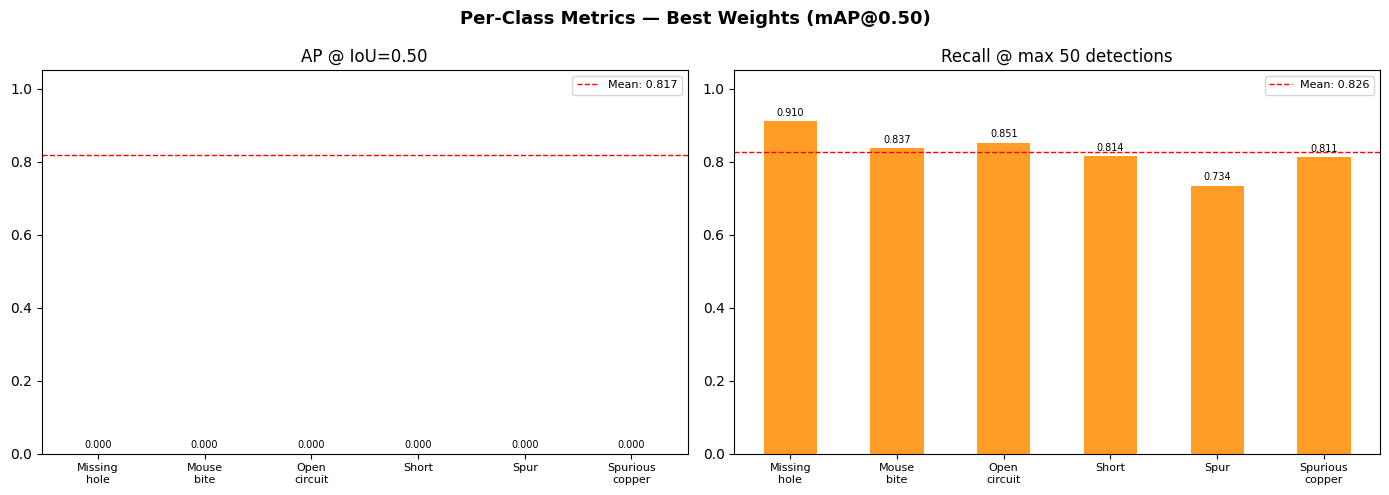

  Saved → eval_outputs/per_class_best.png
  Building confusion matrix...


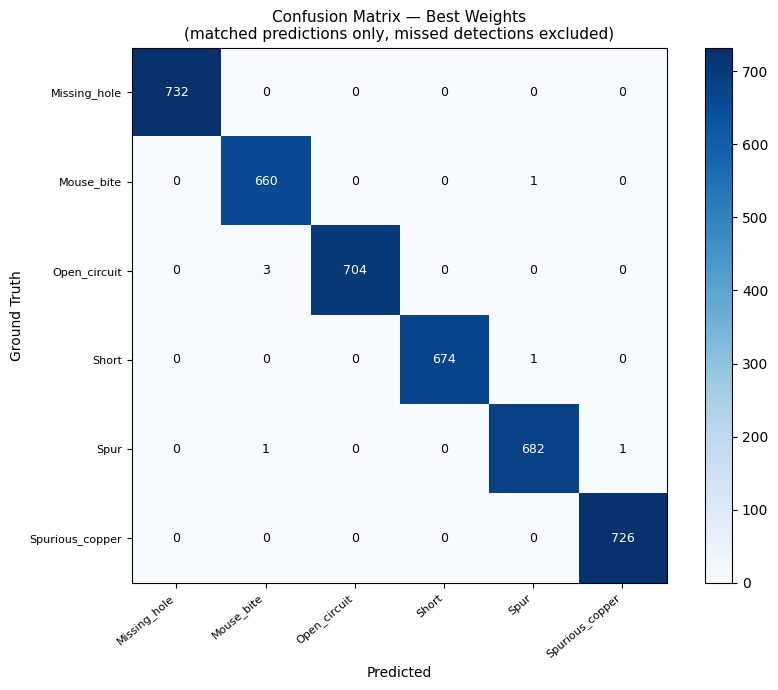


  Miss Rate per Class:
    Missing_hole        :  67/799 missed (8.4%)
    Mouse_bite          : 116/777 missed (14.9%)
    Open_circuit        : 117/824 missed (14.2%)
    Short               : 148/823 missed (18.0%)
    Spur                : 243/927 missed (26.2%)
    Spurious_copper     : 159/885 missed (18.0%)
  Saved → eval_outputs/confusion_best.png
  Generating prediction visualization grid...


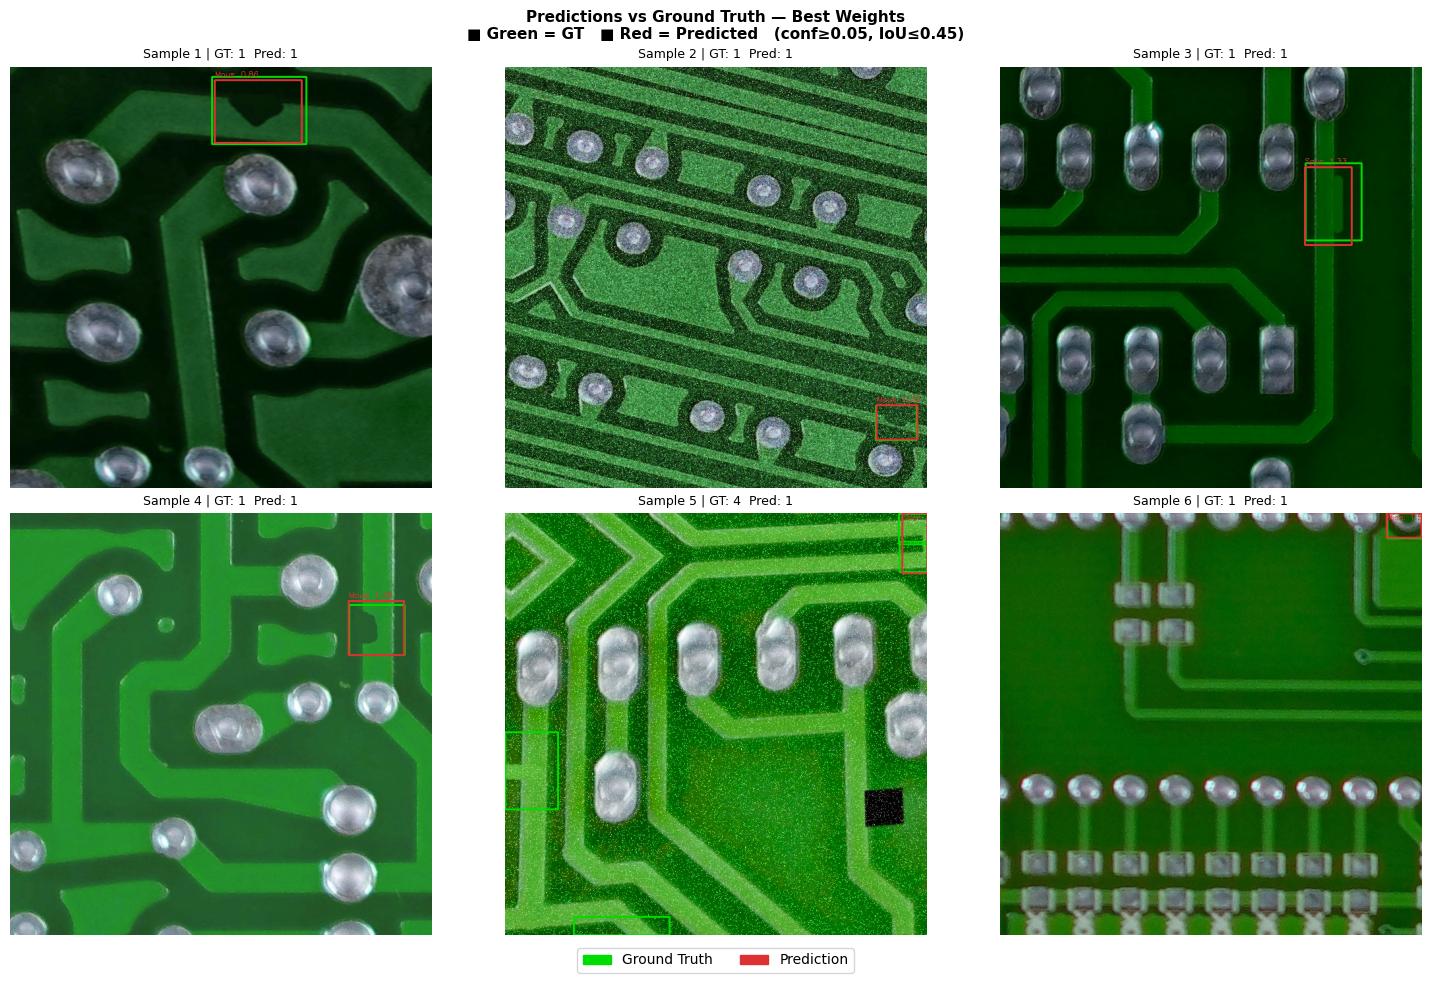

  Saved → eval_outputs/predictions_best.png

  Evaluating: Final (/kaggle/input/models/stayfalz/test/pytorch/model/5/mobilevit_leyolo_final_full.pt)
  Running full metric evaluation...

  Overall Metrics:
    mAP@0.50     : 0.9275
    Recall       : 0.9340

  Per-Class Breakdown:
    Missing_hole        : AP=0.0000 | Recall=0.9712
    Mouse_bite          : AP=0.0000 | Recall=0.9305
    Open_circuit        : AP=0.0000 | Recall=0.9272
    Short               : AP=0.0000 | Recall=0.9149
    Spur                : AP=0.0000 | Recall=0.9213
    Spurious_copper     : AP=0.0000 | Recall=0.9390


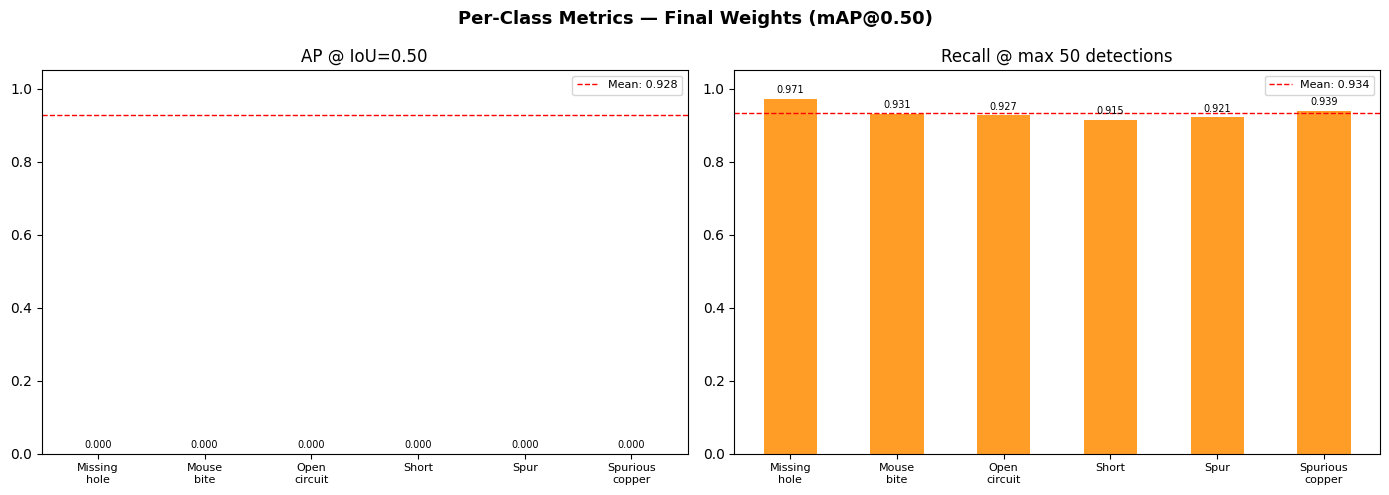

  Saved → eval_outputs/per_class_final.png
  Building confusion matrix...


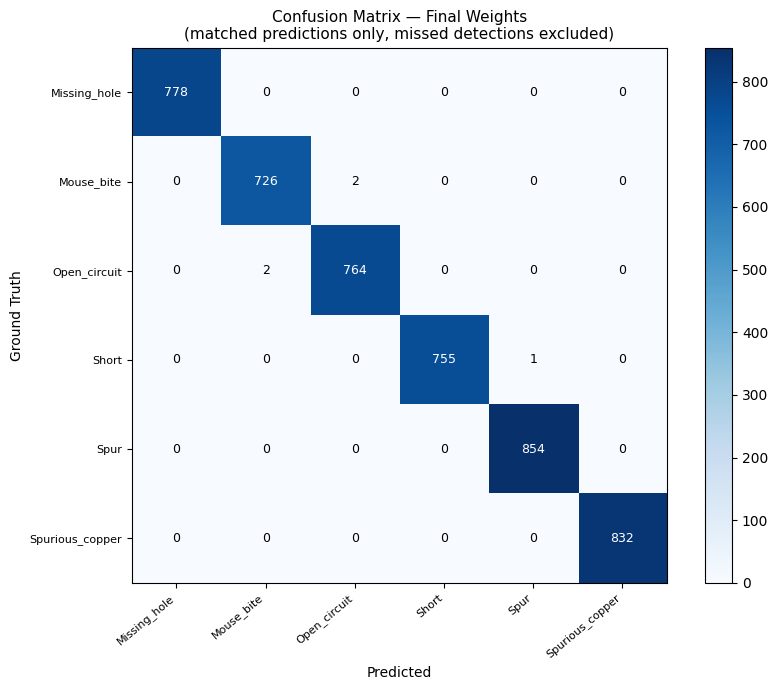


  Miss Rate per Class:
    Missing_hole        :  21/799 missed (2.6%)
    Mouse_bite          :  49/777 missed (6.3%)
    Open_circuit        :  58/824 missed (7.0%)
    Short               :  67/823 missed (8.1%)
    Spur                :  73/927 missed (7.9%)
    Spurious_copper     :  53/885 missed (6.0%)
  Saved → eval_outputs/confusion_final.png
  Generating prediction visualization grid...


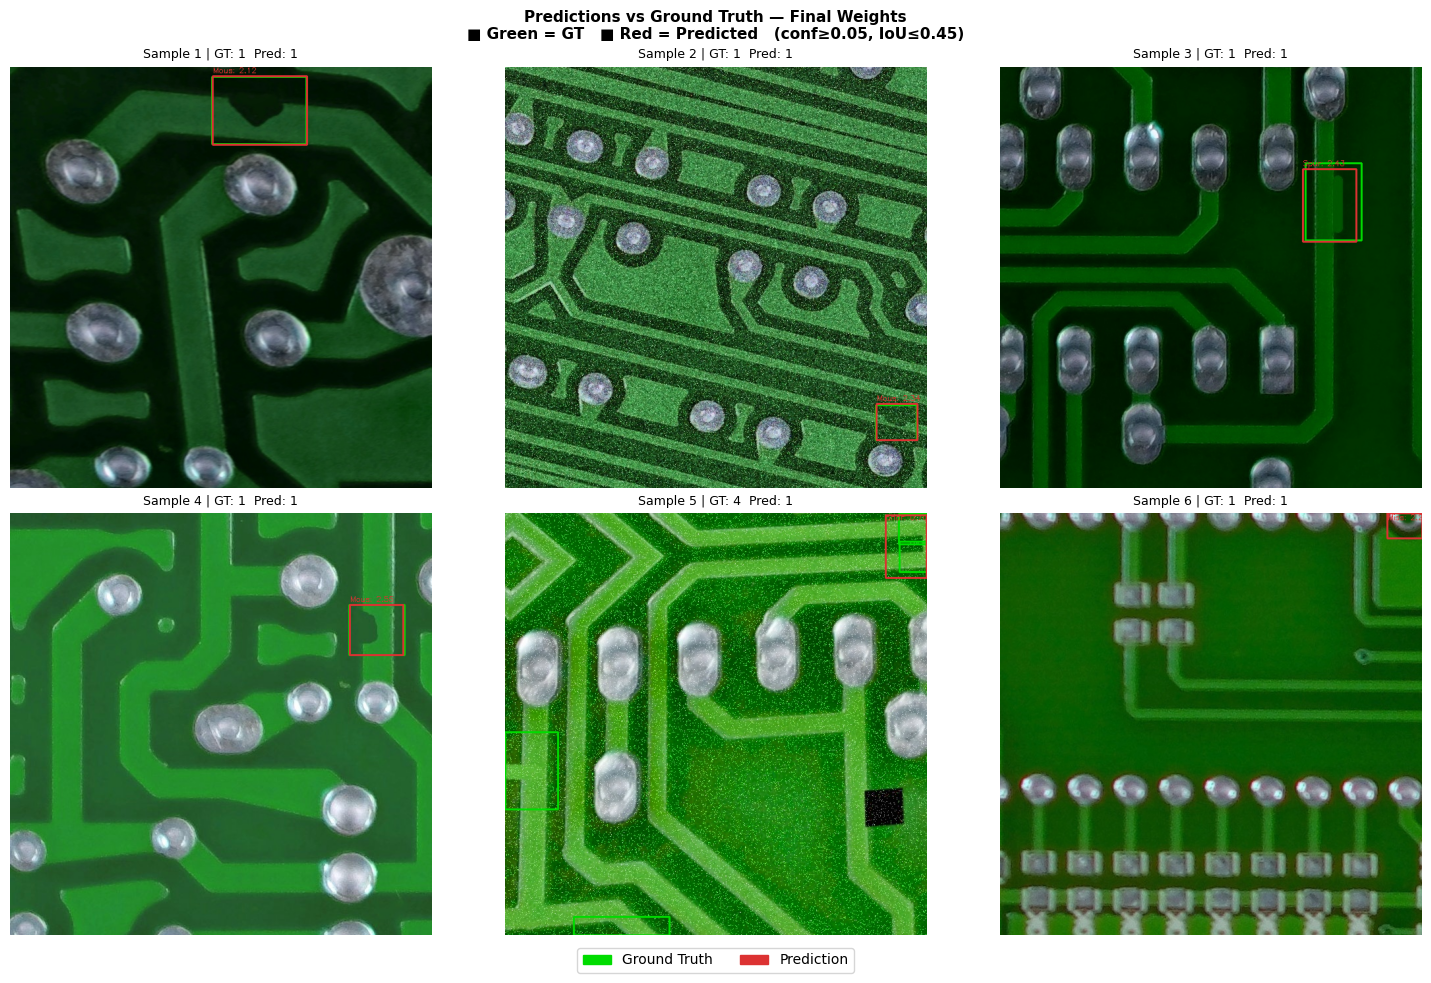

wandb: WARNING Symlinked 6 files into the W&B run directory; call wandb.save again to sync new files.


  Saved → eval_outputs/predictions_final.png

  Generating side-by-side comparison...


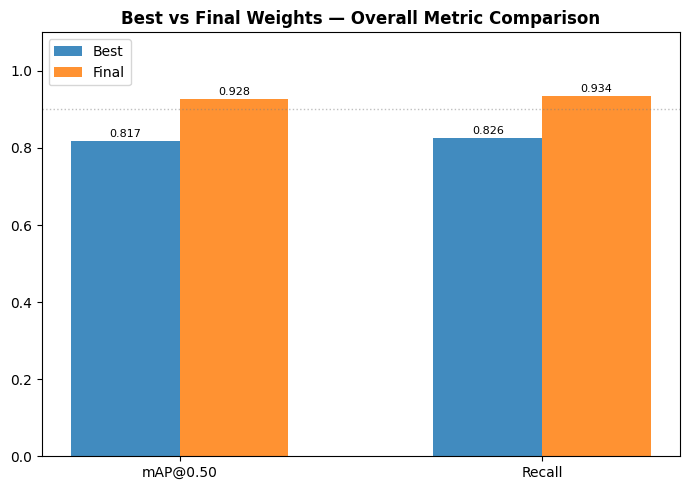

  Saved → eval_outputs/comparison_best_vs_final.png



   Evaluation complete. All outputs saved to: eval_outputs/


In [ ]:
import os
import torch
import torchvision.ops as ops
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.ops import box_iou

# ── USER CONFIG ───────────────────────────────────────────────────────────────
WEIGHT_PATHS = {
    "Best"  : "/kaggle/input/models/stayfalz/test/pytorch/model/5/mobilevit_leyolo_best_full.pt",
    "Final" : "/kaggle/input/models/stayfalz/test/pytorch/model/5/mobilevit_leyolo_final_full.pt",
}
CLASS_NAMES   = ["Missing_hole", "Mouse_bite", "Open_circuit", "Short", "Spur", "Spurious_copper"]
CONF_THRESHOLD = config.conf_threshold
IOU_THRESHOLD  = config.iou_threshold
IMAGE_SIZE     = config.image_size
NUM_VIZ        = 6   # images for prediction grid (2 rows x 3 cols)
DETECT         = 50
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR     = "eval_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ── HELPER: DECODE PREDICTIONS ────────────────────────────────────────────────
def decode_predictions(model, images, conf_threshold=CONF_THRESHOLD, iou_threshold=IOU_THRESHOLD):
    """
    Runs inference and returns NMS-filtered predictions per image.
    Bypasses LeHead's inference concatenation to get raw feature maps.
    """
    model.eval()
    with torch.no_grad():
        # ✅ Run native model forward to get features
        features = model.fpn(model.net(images))

        # Run head box and cls branches per scale — skip the inference decode path
        feats = []
        for i, (box_branch, cls_branch) in enumerate(zip(model.head.box, model.head.cls)):
            f = list(features)[i]
            feats.append(torch.cat([box_branch(f), cls_branch(f)], dim=1))

    box_ch = model.head.ch * 4  # 64
    _, _, H, W = images.shape

    results = []
    for b in range(images.shape[0]):
        boxes_list, scores_list = [], []
        for f in feats:
            B, C, fH, fW = f.shape          # ✅ now guaranteed 4D
            f_flat = f[b].view(C, -1)       # [C, H*W]
            boxes_list.append(f_flat[:box_ch])   # [64, H*W]
            scores_list.append(f_flat[box_ch:])  # [6,  H*W]

        all_boxes  = torch.cat(boxes_list,  dim=1)  # [64, A]
        all_scores = torch.cat(scores_list, dim=1)  # [6,  A]

        max_scores, class_indices = all_scores.max(dim=0)
        conf_mask = max_scores > conf_threshold
        f_scores  = max_scores[conf_mask]
        f_labels  = class_indices[conf_mask]
        f_raw_box = all_boxes[:, conf_mask]  # [64, N]

        # Build anchor grid
        anchor_pts, strides_list = [], []
        for f, stride in zip(feats, model.head.stride.tolist()):
            fH, fW = f.shape[2], f.shape[3]
            ys = torch.arange(fH, device=DEVICE) + 0.5
            xs = torch.arange(fW, device=DEVICE) + 0.5
            gy, gx = torch.meshgrid(ys, xs, indexing='ij')
            anchor_pts.append(torch.stack([gx, gy], dim=-1).view(-1, 2))
            strides_list.append(torch.full((fH * fW,), stride, device=DEVICE))
        anchor_pts   = torch.cat(anchor_pts,   dim=0)
        strides_tens = torch.cat(strides_list, dim=0)

        anc  = anchor_pts[conf_mask]
        strd = strides_tens[conf_mask]

        # DFL decode
        ch      = model.head.ch
        raw_box = f_raw_box.view(4, ch, -1).softmax(1)
        weights = torch.arange(ch, device=DEVICE, dtype=torch.float).view(1, ch, 1)
        dist    = (raw_box * weights).sum(1)  # [4, N]

        x1 = (anc[:, 0] - dist[0]) * strd
        y1 = (anc[:, 1] - dist[1]) * strd
        x2 = (anc[:, 0] + dist[2]) * strd
        y2 = (anc[:, 1] + dist[3]) * strd
        f_boxes_xyxy = torch.stack([x1, y1, x2, y2], dim=1)

        if len(f_boxes_xyxy) > 0:
            keep = ops.nms(f_boxes_xyxy, f_scores, iou_threshold=iou_threshold)
            results.append({
                "boxes":  f_boxes_xyxy[keep].cpu(),
                "scores": f_scores[keep].cpu(),
                "labels": f_labels[keep].cpu(),
            })
        else:
            results.append({
                "boxes":  torch.empty((0, 4)),
                "scores": torch.empty((0,)),
                "labels": torch.empty((0,), dtype=torch.long),
            })
    return results


# ── 1. FULL METRIC EVALUATION ─────────────────────────────────────────────────
def run_full_evaluation(model):
    """Runs mAP evaluation over the entire val_loader."""
    model.eval()
    metric = MeanAveragePrecision(
        box_format='xyxy',
        iou_type='bbox',
        class_metrics=True,
        average='macro',
        iou_thresholds=[0.5], # ✅ Explicitly restrict to mAP@0.50 to avoid -1.0 errors & skip 0.50:0.95
        max_detection_thresholds=[1, 10, 50],
    )
    with torch.no_grad():
        for images, target_dict, _ in val_loader:
            images = images.to(DEVICE)
            _, _, H, W = images.shape
            preds   = decode_predictions(model, images)
            targets = []
            for b in range(images.shape[0]):
                gt_mask  = target_dict['batch_idx'] == b
                gt_boxes = target_dict['bboxes'][gt_mask]
                gt_labels= target_dict['cls'][gt_mask].squeeze(-1).long()
                if len(gt_boxes) > 0:
                    x_c, y_c, bw, bh = gt_boxes.unbind(1)
                    gt_xyxy = torch.stack([
                        (x_c - bw/2)*W, (y_c - bh/2)*H,
                        (x_c + bw/2)*W, (y_c + bh/2)*H,
                    ], dim=1)
                else:
                    gt_xyxy = torch.empty((0, 4))
                targets.append({"boxes": gt_xyxy, "labels": gt_labels})
            metric.update(preds, targets)
    model.train()
    return metric.compute()


# ── 2. CONFUSION MATRIX ───────────────────────────────────────────────────────
def compute_confusion(model):
    """Matches GT boxes to predictions via IoU and builds confusion matrix."""
    model.eval()
    all_gt, all_pred = [], []

    with torch.no_grad():
        for images, target_dict, _ in val_loader:
            images = images.to(DEVICE)
            _, _, H, W = images.shape
            preds = decode_predictions(model, images)

            for b in range(images.shape[0]):
                gt_mask   = target_dict['batch_idx'] == b
                gt_boxes  = target_dict['bboxes'][gt_mask]
                gt_labels = target_dict['cls'][gt_mask].squeeze(-1).long()
                if len(gt_boxes) == 0:
                    continue
                x_c, y_c, bw, bh = gt_boxes.unbind(1)
                gt_xyxy = torch.stack([
                    (x_c - bw/2)*W, (y_c - bh/2)*H,
                    (x_c + bw/2)*W, (y_c + bh/2)*H,
                ], dim=1)
                p = preds[b]
                if len(p["boxes"]) == 0:
                    all_gt.extend(gt_labels.tolist())
                    all_pred.extend([-1] * len(gt_labels))
                    continue
                iou_mat = box_iou(gt_xyxy, p["boxes"])
                for gi, gl in enumerate(gt_labels):
                    best_iou, best_pi = iou_mat[gi].max(dim=0)
                    if best_iou > IOU_THRESHOLD:
                        all_gt.append(gl.item())
                        all_pred.append(p["labels"][best_pi].item())
                    else:
                        all_gt.append(gl.item())
                        all_pred.append(-1)
    model.train()
    return all_gt, all_pred


# ── 3. VISUALIZATION GRID ─────────────────────────────────────────────────────
def draw_boxes_on_image(raw_img, gt_boxes_norm, pred_result, H, W):
    """Returns an annotated copy of raw_img with GT (green) and pred (red) boxes."""
    img = raw_img.copy()
    # GT boxes
    for box in gt_boxes_norm:
        x_c, y_c, bw, bh = box.cpu().numpy()
        x1, y1 = int((x_c - bw/2)*W), int((y_c - bh/2)*H)
        x2, y2 = int((x_c + bw/2)*W), int((y_c + bh/2)*H)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 220, 0), 2)
    # Predicted boxes
    for box, score, label in zip(
        pred_result["boxes"], pred_result["scores"], pred_result["labels"]
    ):
        x1, y1, x2, y2 = box.int().tolist()
        cls_name = CLASS_NAMES[label.item()] if label.item() < len(CLASS_NAMES) else f"cls{label}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (50, 50, 220), 2)     # ✅ BGR red
        cv2.putText(img, f"{cls_name[:4]}: {score:.2f}",
                    (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (50, 50, 220), 1) # ✅ BGR red
    return img


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN EVALUATION LOOP — runs for each weight file
# ══════════════════════════════════════════════════════════════════════════════
all_results = {}  # store results for comparison plot

for weight_name, weight_path in WEIGHT_PATHS.items():
    if not os.path.exists(weight_path):
        print(f"⚠ {weight_path} not found — skipping {weight_name}")
        continue

    print(f"\n{'='*60}")
    print(f"  Evaluating: {weight_name} ({weight_path})")
    print(f"{'='*60}")

    # Load weights
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.to(DEVICE)

    # ── A. METRIC EVALUATION ──────────────────────────────────────────────────
    print("  Running full metric evaluation...")
    results = run_full_evaluation(model)
    all_results[weight_name] = results

    # With iou_thresholds=[0.5] forced, 'map' represents mAP@0.50
    map50    = results.get('map_50', results.get('map', torch.tensor(0.0))).item()
    recall   = results.get('mar_50', results.get('mar_100', results.get('mar_max_dets', torch.tensor(0.0)))).item()
    
    per_ap   = results.get('map_50_per_class', results.get('map_per_class', None))
    per_rec  = results.get('mar_50_per_class', results.get('mar_100_per_class', None))

    print("\n  Overall Metrics:")
    print(f"    mAP@0.50     : {map50:.4f}")
    print(f"    Recall       : {recall:.4f}")

    if per_ap is not None and not (isinstance(per_ap, torch.Tensor) and per_ap.numel() == 1 and per_ap.item() == -1.0):
        print("\n  Per-Class Breakdown:")
        # Some versions return list/tensors, normalize it
        ap_list  = per_ap.tolist() if isinstance(per_ap, torch.Tensor) else per_ap
        rec_list = per_rec.tolist() if isinstance(per_rec, torch.Tensor) else per_rec

        # Only map up to available bounds
        max_idx = min(len(CLASS_NAMES), len(ap_list))
        for i in range(max_idx):
            ap_val = ap_list[i] if ap_list[i] != -1 else 0.0
            rec_val = rec_list[i] if rec_list is not None and len(rec_list) > i and rec_list[i] != -1 else 0.0
            print(f"    {CLASS_NAMES[i]:20s}: AP={ap_val:.4f} | Recall={rec_val:.4f}")

        # ── B. PER-CLASS BAR CHART ────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Per-Class Metrics — {weight_name} Weights (mAP@0.50)", fontsize=13, fontweight='bold')

        x     = np.arange(max_idx)
        width = 0.5
        short = [n.replace("_", "\n") for n in CLASS_NAMES[:max_idx]]
        
        # Replace remaining -1 with 0 for plotting
        plot_ap = np.array([v if v != -1 else 0.0 for v in ap_list[:max_idx]])
        plot_rec = np.array([v if v != -1 else 0.0 for v in (rec_list[:max_idx] if rec_list else [0]*max_idx)])

        # AP chart
        bars = axes[0].bar(x, plot_ap, width, color='steelblue', alpha=0.85)
        axes[0].set_title("AP @ IoU=0.50")
        axes[0].set_xticks(x); axes[0].set_xticklabels(short, fontsize=8)
        axes[0].set_ylim(0, 1.05)
        axes[0].axhline(map50, color='red', linestyle='--', linewidth=1, label=f"Mean: {map50:.3f}")
        axes[0].legend(fontsize=8)
        for bar, val in zip(bars, plot_ap):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                         f"{val:.3f}", ha='center', va='bottom', fontsize=7)

        # Recall chart
        bars = axes[1].bar(x, plot_rec, width, color='darkorange', alpha=0.85)
        axes[1].set_title(f"Recall @ max {DETECT} detections")
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(short, fontsize=8)
        axes[1].set_ylim(0, 1.05)
        axes[1].axhline(recall, color='red', linestyle='--', linewidth=1, label=f"Mean: {recall:.3f}")
        axes[1].legend(fontsize=8)
        for bar, val in zip(bars, plot_rec):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                         f"{val:.3f}", ha='center', va='bottom', fontsize=7)

        plt.tight_layout()
        out_path = os.path.join(OUTPUT_DIR, f"per_class_{weight_name.lower()}.png")
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved → {out_path}")
    else:
        print("\n  ⚠ Per-Class Breakdown skipped: TorchMetrics returned empty or -1.0 global tensor for 'map_per_class'")

    # ── C. CONFUSION MATRIX ───────────────────────────────────────────────────
    print("  Building confusion matrix...")
    all_gt, all_pred = compute_confusion(model)

    matched  = [(g, p) for g, p in zip(all_gt, all_pred) if p != -1]
    missed   = [(g, p) for g, p in zip(all_gt, all_pred) if p == -1]
    nc       = len(CLASS_NAMES)
    cm       = np.zeros((nc, nc), dtype=int)
    for g, p in matched:
        if 0 <= g < nc and 0 <= p < nc:
            cm[g][p] += 1

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"Confusion Matrix — {weight_name} Weights\n(matched predictions only, missed detections excluded)", fontsize=11)
    ax.set_xticks(range(nc))
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(nc))
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_ylabel("Ground Truth")
    ax.set_xlabel("Predicted")
    thresh = cm.max() / 2
    for i in range(nc):
        for j in range(nc):
            ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                    color='white' if cm[i][j] > thresh else 'black', fontsize=9)
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"confusion_{weight_name.lower()}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Miss rate summary
    print("\n  Miss Rate per Class:")
    for cls_id, name in enumerate(CLASS_NAMES):
        total  = sum(1 for g in all_gt if g == cls_id)
        missed_count = sum(1 for g, p in zip(all_gt, all_pred) if g == cls_id and p == -1)
        pct    = 100 * missed_count / total if total > 0 else 0
        print(f"    {name:20s}: {missed_count:3d}/{total:3d} missed ({pct:.1f}%)")

    print(f"  Saved → {out_path}")

    # ── D. PREDICTION VISUALIZATION GRID (2x3) ────────────────────────────────
    print("  Generating prediction visualization grid...")
    model.eval()

    # Collect fixed samples from val_loader
    samples = []
    for imgs, tgts, raws in val_loader:
        for b in range(imgs.shape[0]):
            samples.append((imgs[b:b+1], tgts, raws[b], b))
            if len(samples) >= NUM_VIZ:
                break
        if len(samples) >= NUM_VIZ:
            break

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Predictions vs Ground Truth — {weight_name} Weights\n"
                 f"■ Green = GT   ■ Red = Predicted   (conf≥{CONF_THRESHOLD}, IoU≤{IOU_THRESHOLD})",
                 fontsize=11, fontweight='bold')

    for ax_idx, (img_tensor, tgts, raw_img, b_idx) in enumerate(samples[:NUM_VIZ]):
        row, col = divmod(ax_idx, 3)
        ax = axes[row][col]

        img_tensor = img_tensor.to(DEVICE)
        H, W, _    = raw_img.shape
        pred_result = decode_predictions(model, img_tensor)[0]

        gt_mask = tgts['batch_idx'] == b_idx
        gt_boxes = tgts['bboxes'][gt_mask]

        annotated = draw_boxes_on_image(raw_img, gt_boxes, pred_result, H, W)
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB) if annotated.shape[2] == 3 else annotated)

        n_gt   = len(gt_boxes)
        n_pred = len(pred_result["boxes"])
        ax.set_title(f"Sample {ax_idx+1} | GT: {n_gt}  Pred: {n_pred}", fontsize=9)
        ax.axis('off')

    # Legend
    gt_patch   = mpatches.Patch(color=(0, 220/255, 0),    label='Ground Truth')
    pred_patch = mpatches.Patch(color=(220/255, 50/255, 50/255), label='Prediction')
    fig.legend(handles=[gt_patch, pred_patch], loc='lower center', ncol=2,
               fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    out_path = os.path.join(OUTPUT_DIR, f"predictions_{weight_name.lower()}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")


# ── E. SIDE-BY-SIDE COMPARISON PLOT (Best vs Final) ──────────────────────────
if len(all_results) == 2:
    print(f"\n{'='*60}")
    print("  Generating side-by-side comparison...")

    names    = list(all_results.keys())
    metrics  = ["mAP@0.50", "Recall"]
    vals     = {
        n: [
            all_results[n].get('map_50', all_results[n].get('map', torch.tensor(0.0))).item(),
            all_results[n].get('mar_50', all_results[n].get('mar_100', all_results[n].get('mar_max_dets', torch.tensor(0.0)))).item(),
        ] for n in names
    }

    x     = np.arange(len(metrics))

    if wandb.run is not None:
        # wandb.save tracks the directory and will sync all files (including the final plot) at the end of the run
        wandb.save(f"{OUTPUT_DIR}/*", base_path="./")
        
    width = 0.3
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title("Best vs Final Weights — Overall Metric Comparison", fontsize=12, fontweight='bold')

    for i, name in enumerate(names):
        bars = ax.bar(x + i*width, vals[name], width, label=name, alpha=0.85)
        for bar, val in zip(bars, vals[name]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=10)
    ax.axhline(0.9, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='0.90 target')

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "comparison_best_vs_final.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")

wandb.finish()
print(f"\n   Evaluation complete. All outputs saved to: {OUTPUT_DIR}/")